## Collision analysis
Takes stim data from a given session and stim polarity/amplitude and find putative collision cells. Uses changepoint detection to find potential collision points and compares to a shuffle distribution. Also allows you to toggle through the hash for putative collision cells to view responses at different latencies to manually check collisions.

Saves basic features of the cells with collisions in a collision properties dict **collision_props_{stim_pol}.npy** in the session folder, for use in making figures with collision_plots.ipynb.

In [1]:
import numpy as np

from scipy import stats
from scipy.spatial import distance as dist

import matplotlib.pyplot as plt

import format_chronic_stim
import stim_plots

import sys
sys.path.append("..//neural/")
import format_waveform_data
import wormhole_analysis as analysis

import scipy.io
import os

In [2]:
''' set paths '''
# set parent directory
root_dir = "Z:/Isabel/data/hpc_implants/" # locker
# root_dir = "../data/antidromic_stim/" # local

# session params
bird_id = "AMB154"
session_id = "241122"
ephys_id = "AMB154_241122_110236"
stim_pol = "neg"
show_plots = True
only_good = True

# data dirs
session_dir = f"{root_dir}{bird_id}/{bird_id}_{session_id}/{ephys_id}/" # locker
# session_dir = f"{root_dir}{bird_id}/{bird_id}_{session_id}/" # local
ks_dir = "kilosort4_blanked/"
ephys_dir = f"{session_dir}raw_ephys_output/"

In [3]:
''' basic params '''
sampling_rate = 30000
t_pre = 0.02 # seconds collected before stim starts
t_post = 0.03 # seconds collected after stim time

### Load and preprocess the data

In [4]:
''' load and preprocess the stim data '''
raw_ephys = format_chronic_stim.load_stim(ephys_dir, stim_pol=stim_pol)
sorted_ephys, ch_names = format_chronic_stim.sort_stim_by_channel(ephys_dir, raw_ephys)
[n_channels, n_samples, n_stim] = sorted_ephys.shape

# get the stim times
stim_times = np.load(f'{ephys_dir}stim_t_{stim_pol}.npy')
stim_times = np.squeeze(stim_times.astype(int))

assert(stim_times.shape[0]==n_stim)

loaded 1247 stim events in 3.503265100007411 seconds
Z:/Isabel/data/hpc_implants/AMB154/AMB154_241122/AMB154_241122_110236/raw_ephys_output/intan_info.mat


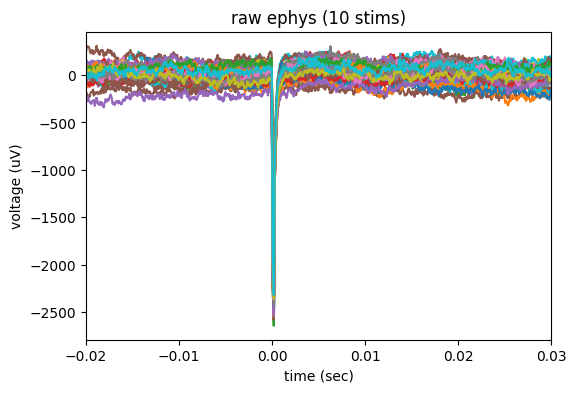

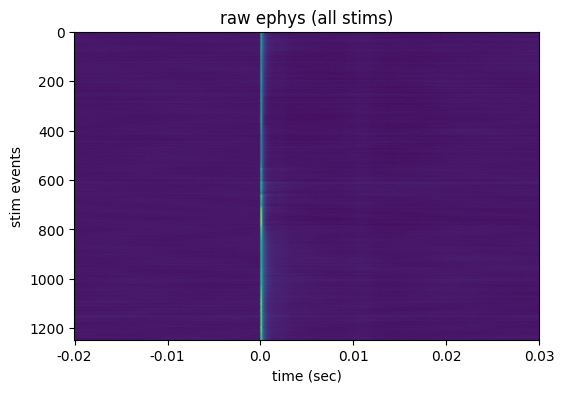

In [5]:
''' check the raw data to see how it looks '''
if show_plots:
    f, ax = stim_plots.plot_raw_ephys(sorted_ephys, ch_num=29, ex_trials=[400, 450])
    plt.show()

In [1]:
# broken_channels = np.asarray([23, 48, 51, 63]) #IND67
# A-03-3, A-17-1, A-20-2, A-21-1, B-07-3, B-12-2, B-13-3, B-17-3, B-21-1, B-22-2
# broken_channels = np.asarray([3, 23, 28, 29, 41, 48, 50, 56, 61, 63]) # AMB154 241119
# broken_channels = np.asarray([3, 23, 28, 29, 41, 48, 50, 56, 61, 63]) # AMB154 241119
# broken_channels = np.asarray([3, 23, 28, 29, 41, 48, 56, 59, 61]) # AMB154 241127
# broken_channels = np.asarray([3, 23, 28, 29, 41, 48, 54, 56, 59, 61, 63]) # AMB154 241202
broken_channels = np.asarray([53, 56, 63]) 
for ch in broken_channels:
    print(ch_names[ch])

NameError: name 'np' is not defined

In [6]:
'''
LIM63 broken: A-11-1, A-16-2, B-12-2
broken_channels = np.asarray([14, 22, 48])

AMB154 broken
np.asarray([3, 23, 28, 29, 41, 48, 50, 56, 59, 61])
np.asarray([3, 23, 28, 29, 41, 48, 50, 56, 61, 63]) 241119
np.asarray([3, 23, 28, 29, 41, 48, 56, 59, 61]) 241127
np.asarray([3, 23, 28, 29, 41, 48, 54, 56, 59, 61, 63]) 241202

SLV132 broken: B-07-1, B-09-1, B-11-1, B-15-3, B-17-3, B-22-2
np.asarray([40, 46, 53, 56, 63])
'''
broken_channels = np.asarray([3, 23, 28, 29, 41, 48, 50, 56, 61, 63])
start_idx = 0
end_idx = n_stim

ephys_data, ch_names = format_chronic_stim.trim_stim_data(sorted_ephys, ch_names,
                                                          broken_ch=broken_channels,
                                                          start_idx=start_idx, end_idx=end_idx)

# get indices for each shank
A_shank = []
B_shank = []
for i, ch in enumerate(ch_names):
    if 'A' in ch:
        A_shank.append(i)
    else:
        B_shank.append(i)
A_shank = np.asarray(A_shank)
B_shank = np.asarray(B_shank)

# data params
[n_channels, n_samples, n_stim] = ephys_data.shape
stim_times = stim_times[start_idx:end_idx]
assert(stim_times.shape[0]==n_stim)
print(f"n channels = {n_channels}, samples = {n_samples}, stim events = {n_stim}")

n channels = 54, samples = 1500, stim events = 1247


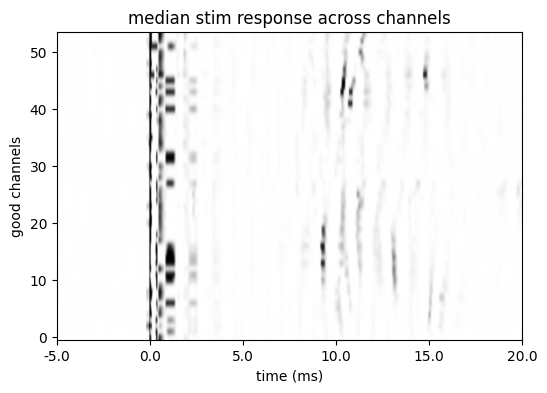

In [7]:
''' filter stim data and plot median stim event for all channels '''
filt_data = format_chronic_stim.filter_stim_for_spikes(ephys_data)
if show_plots:
    f, ax = stim_plots.plot_avg_stim(filt_data, v_max=40)
    plt.show()

In [8]:
''' load and format the waveform struct '''
waveform_struct = format_waveform_data.load_wf_data(session_dir, ks_dir=ks_dir)
wf_ids = waveform_struct['goodIDs']
mean_waveforms, wf_channels, _ = format_waveform_data.sort_wf_by_channel('', waveform_struct,
                                                                                 data_dir=ephys_dir)
# filter out the bad channels and get the new channel index
all_ch = np.arange(mean_waveforms.shape[1])
good_idx = np.setdiff1d(all_ch, broken_channels)
mean_waveforms = mean_waveforms[:, good_idx]
wf_ch_idx = np.asarray([ch_names.index(ch) for ch in wf_channels])

n_cells = mean_waveforms.shape[0]

Z:/Isabel/data/hpc_implants/AMB154/AMB154_241122/AMB154_241122_110236/kilosort4_blanked/waveformStruct.mat
dict_keys(['mxWF', 'max_site', 'pcWF', 'meanRate', 'waveFormsMean', 'spkDur', 'spkOffset', 'goodIDs', 'goodLabels', 'medISI', 'contam', 'nSpikes'])
Z:/Isabel/data/hpc_implants/AMB154/AMB154_241122/AMB154_241122_110236/raw_ephys_output/intan_info.mat


In [9]:
good_clusters, spike_id, spike_t = format_waveform_data.get_spike_times(session_dir, ks_dir=ks_dir)
assert good_clusters.shape[0] == n_cells
pre_stim_spikes = analysis.get_pre_stim_spikes(stim_times, spike_id, spike_t, sampling_rate=sampling_rate)

### Isolate consistent antidromic responses to stim

In [10]:
'''
get the hash - consistent antidromic responses to stim 
crop to a range that captures all antidromic responses
'''
buffer = 6
start_t = 5e-3
end_t = 15e-3
start_idx = np.round((t_pre + start_t)*sampling_rate).astype(int)
end_idx = np.round((t_pre + end_t)*sampling_rate).astype(int)

# select time window and re-order axes to be shape (n_trials, n_channels, n_samples)
stim_hash = np.moveaxis(filt_data[:, start_idx:end_idx], -1, 0)
n_samp = stim_hash.shape[-1]
avg_hash = np.mean(stim_hash, axis=0)
print(avg_hash.shape)

(54, 300)


In [11]:
''' define a cropping mask around the antidromic spikes '''
# cropping params
spk_thresh = 25 # minimum spike amplitude in uV
spk_half_samp = 6 # n samples to include on each side of the spike
spk_half_ch = 4 # n channels to include on each side of the spike

#  define mask
mask = np.zeros_like(avg_hash).astype(bool)
for i in range(n_channels):
    for j in range(n_samp):
        if np.abs(avg_hash[i, j]) >= spk_thresh:
            ch_start = np.max([i-spk_half_ch, 0])
            ch_end = np.min([i+spk_half_ch+1, n_channels])
            samp_start = np.max([j-spk_half_samp, 0])
            samp_end = np.min([j+spk_half_samp+1, n_samp])
            mask[ch_start:ch_end, samp_start:samp_end] = True
            
# define channels with an antidromic response (worm)
worm_ch_idx = np.zeros(n_channels).astype(bool)
for i in range(n_channels):
    if any(np.abs(avg_hash[i]) >= spk_thresh):
        worm_ch_idx[i] = True
worm_channels = np.arange(n_channels)[worm_ch_idx]

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Isabel\AppData\Local\Temp\ipykernel_107312\2338278904.py:12: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f'cropping mask, spike threshold = {spk_thresh} $\mu$V')


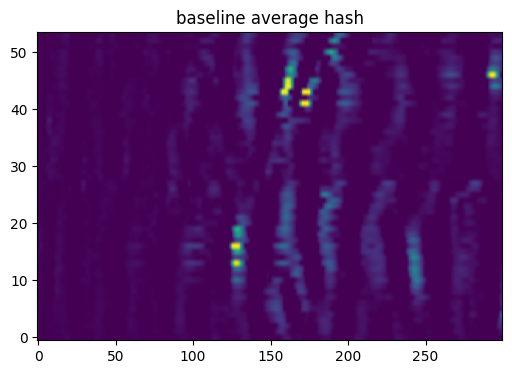

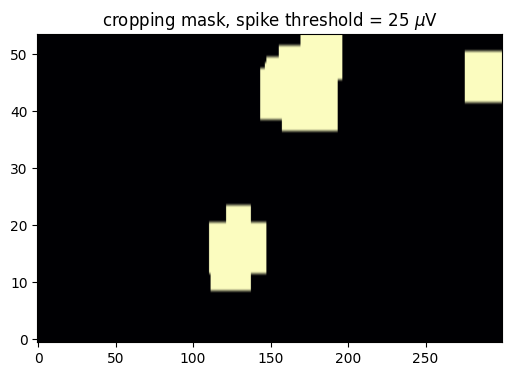

In [12]:
''' plot the raw hash and the clipping mask '''
f, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.imshow(-avg_hash, clim=[0, 50],
          aspect='auto', cmap='viridis')
ax.set_title('baseline average hash')
ax.set_ylim(ax.get_ylim()[::-1])
plt.show()

f, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.imshow(mask, clim=[0, 1],
          aspect='auto', cmap='magma')
ax.set_title(f'cropping mask, spike threshold = {spk_thresh} $\mu$V')
ax.set_ylim(ax.get_ylim()[::-1])
plt.show()

### Changepoint detection
**Method:** Collect a set of putative collision trials (n_short: trials with a spike $<l$ before the stim) and a large set of non-collision trials into a matrix $A$ of shape (n_trials, n_channels * n_samples). Sort these trials by latency of the most recent spike before the stim event. Use the mask $M$ (created above from the baseline average hash), which is 1 around spikes and 0 everywhere else. Take the element-wise product $A \otimes M = A_M$ to crop out spikes not present in the baseline average stim response. Note that new spikes (not stim-evoked) that are on top of or near spikes from the baseline are still included... To account for slight jitter in the spike latencies, take the absolute value $|A_M|$.

**Now, use modified change point detection** to find the trial index with the greatest change in the hash. For cells with collisions, we expect the hash to look different when pre-stim spikes occur within a certain latency (the collision latency) of the stim event. Use the method described by [Fearnhead, P., & Fryzlewicz, P. (2022)](https://arxiv.org/pdf/2210.07066) to detect a single change point, modified to find changes between vectors (average of a matrix, preserving space/time structure) instead of changes between scalar means. We will look for change points specifically within the range of possible hash (latency $<l$). This method also outputs the likelihood ratio statistic, which captures the magnitude of the change (how likely is it that the means are truly different, normalized by the number of trials in each set) and which can be compared to a shuffle distribution.

cell 0 no response on best channel
cell 7 no response on best channel
cell 11 no response on best channel
cell 19 no response on best channel
cell 21 no response on best channel
cell 23 no response on best channel
cell 25 no response on best channel
cell 26 no response on best channel
cell 27 no response on best channel
cell 29 no response on best channel
cell 31 no response on best channel
cell 32 no response on best channel
cell 34 no response on best channel
cell 39 no response on best channel
cell 40 no response on best channel
cell 41 no response on best channel
cell 42 no response on best channel
cell 43 no response on best channel
cell 44 no response on best channel
cell 49 no response on best channel
cell 51 no response on best channel
cell 52 no response on best channel
cell 55 no response on best channel
cell 60 no response on best channel
cell 62 no response on best channel
cell 64 no response on best channel
cell 69 no response on best channel
cell 70 no response on best ch

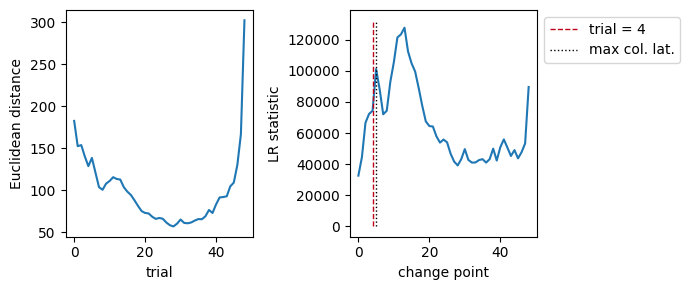

cell 175 no response on best channel
cell 187 only 30 spikes
cell 194 no response on best channel
cell 196 no response on best channel
cell 197 no response on best channel
cell 205: 7 possible collision trials


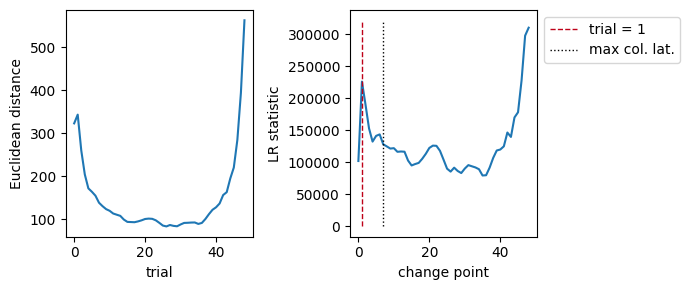

cell 215: 25 possible collision trials


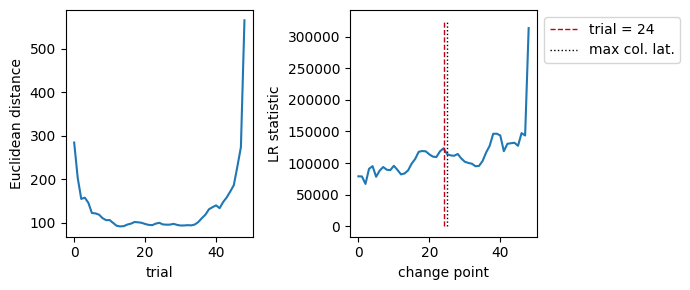

cell 216 no response on best channel
cell 220 no response on best channel
cell 221 no response on best channel
cell 222 no response on best channel
cell 226 no response on best channel
cell 232 no response on best channel
cell 234 no response on best channel
cell 246 no response on best channel
cell 250 no response on best channel
cell 256 no response on best channel
cell 258 no response on best channel
cell 260 no response on best channel
cell 261 no response on best channel
cell 262 no response on best channel
cell 267 no response on best channel
cell 268 no response on best channel
cell 282 no response on best channel
cell 287 no response on best channel
cell 288 no response on best channel
cell 297 no response on best channel
cell 299 no response on best channel
cell 303 no response on best channel
cell 307 no response on best channel
cell 313 no response on best channel
cell 317 no response on best channel
cell 319 no response on best channel
cell 321 only 14 spikes
cell 322 no re

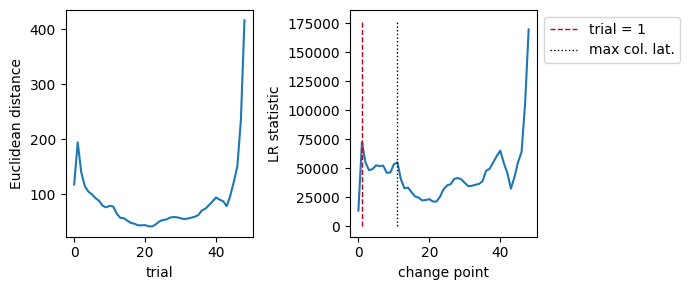

cell 387 no response on best channel
cell 391: 5 possible collision trials


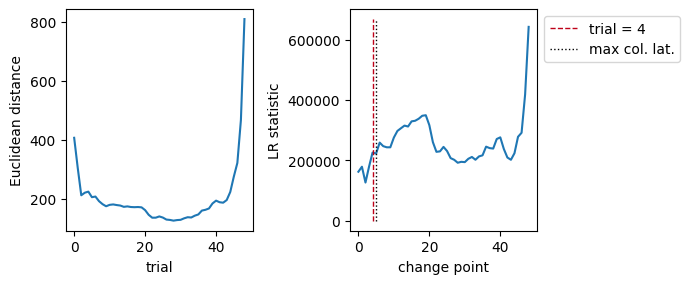

cell 395 only 16 spikes
cell 396: 8 possible collision trials


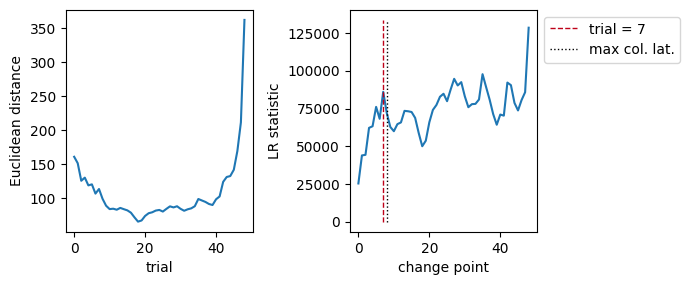

cell 401 only 7 spikes
cell 404: 3 possible collision trials


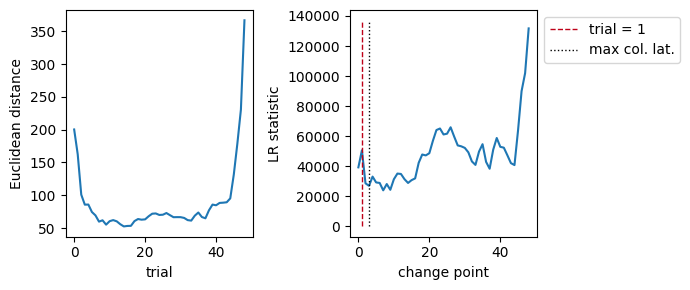

cell 406 only 30 spikes
cell 407: 8 possible collision trials


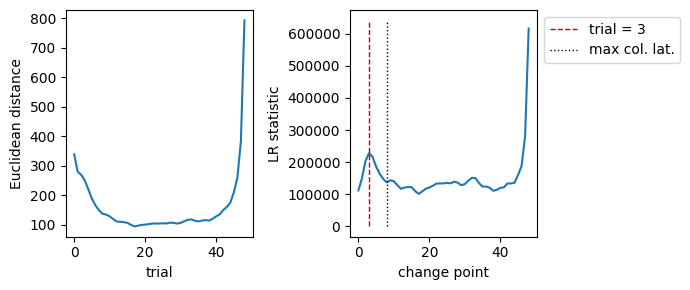

cell 408: 25 possible collision trials


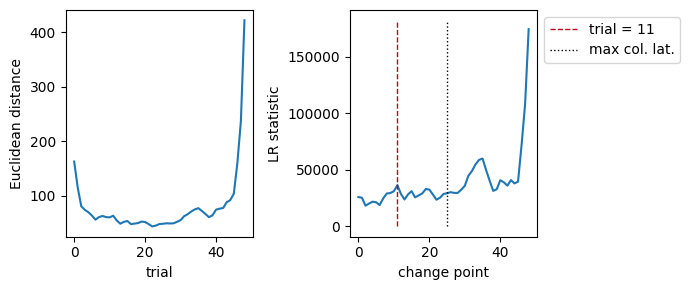

cell 414 only 34 spikes
cell 420 only 11 spikes
cell 421 no response on best channel
cell 425 only 3 spikes
cell 426 only 7 spikes
cell 433: 1 possible collision trials


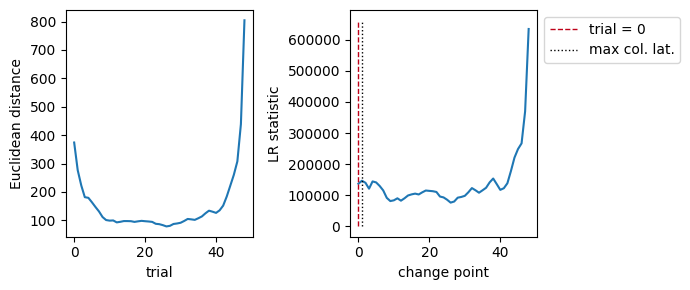

cell 437 no response on best channel
cell 441 only 14 spikes
cell 445 only 14 spikes
cell 470 only 1 spikes
cell 474 only 11 spikes
cell 491 no response on best channel
cell 493 only 5 spikes
cell 495 no response on best channel
cell 499 no response on best channel
cell 501 no response on best channel
cell 505 no response on best channel
cell 509 no response on best channel
cell 510: 25 possible collision trials


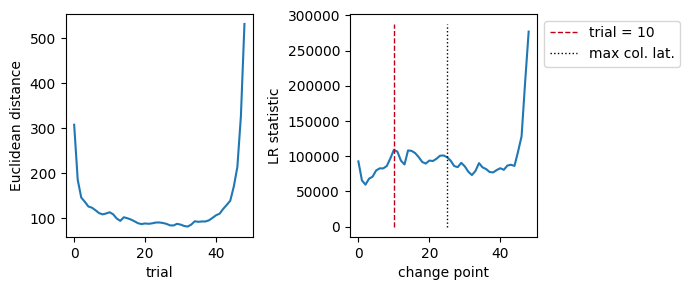

cell 512 no response on best channel
cell 524 no response on best channel
cell 528 no response on best channel
cell 530 no response on best channel
cell 532 no response on best channel
cell 536 no response on best channel
cell 538 no response on best channel
cell 539 no response on best channel
cell 540 no response on best channel


In [13]:
''' Detect possible change points for each cell '''
# analysis params
max_latency = 20e-3 # maximum latency at which we expect collisions
min_latency_long = 25e-3 # minimum latency for a trial to be included in the baseline average
n_wf_ch = spk_half_ch*2 + 1 # number of channels to take
n_trials = 50 # number of stim trials to take

# pre-allocate vars
all_trial_idx = []
all_hash_all_cells = []
all_LR_all_cells = []
all_change_LR = np.full(n_cells, np.NaN)
all_change_idx = np.full(n_cells, np.NaN)
all_n_short = np.full(n_cells, np.NaN)
all_change_lat = np.full(n_cells, np.NaN)
all_LR_latencies = np.full((n_cells, n_trials), np.NaN)

for cell in range(n_cells):
    # data params
    pre_stim_lat = pre_stim_spikes[cell]
    best_ch = wf_ch_idx[cell]
    
    # check if there is a worm on the best channel
    if not(best_ch in worm_channels):
        print(f"cell {good_clusters[cell]} no response on best channel")
        all_LR_all_cells.append([])
        all_trial_idx.append(np.asarray([]))
        all_hash_all_cells.append(np.asarray([]))
        continue

    # sort by latency to stim
    lat_sort_idx = np.argsort(pre_stim_lat)
    sorted_latencies = pre_stim_lat[lat_sort_idx]
    if np.sum(np.isfinite(sorted_latencies)) < n_trials:
        print(f"cell {good_clusters[cell]} only {np.sum(np.isfinite(sorted_latencies))} spikes")
        all_LR_all_cells.append([])
        all_trial_idx.append(np.asarray([]))
        all_hash_all_cells.append(np.asarray([]))
        continue

    # grab the relevant hash
    lat_trial_idx, n_short = analysis.subsample_trials(sorted_latencies,
                                                       n_trials=n_trials,
                                                       min_thresh=min_latency_long,
                                                       collision_thresh=max_latency)
    if n_short:
        # grab the relevant hash - possible collision trials
        print(f"cell {good_clusters[cell]}: {n_short} possible collision trials")   
        hash_trial_idx = lat_sort_idx[lat_trial_idx]
        hash_ch_idx = analysis.subsample_channels(best_ch, A_shank=A_shank,
                                                  B_shank=B_shank, n_wf_ch=n_wf_ch)
        hash_subsamp = stim_hash[hash_trial_idx]
        hash_masked = hash_subsamp[:, hash_ch_idx] * mask[None, hash_ch_idx]
        hash_unwrapped = np.reshape(hash_masked, [n_trials, -1])

        # get the change point
        LR, change_idx = analysis.one_changepoint_vectors(np.abs(hash_unwrapped),
                                                                 max_col_trial=n_short,
                                                                 show_plots=True)
        change_LR = LR[change_idx]
        change_lat = sorted_latencies[lat_trial_idx][change_idx]
        
        # save everything
        all_trial_idx.append(hash_trial_idx)
        all_hash_all_cells.append(hash_masked)
        all_LR_all_cells.append(LR)
        all_change_LR[cell] = change_LR
        all_change_idx[cell] = change_idx
        all_n_short[cell] = n_short
        all_change_lat[cell] = sorted_latencies[change_idx]
        all_LR_latencies[cell] = sorted_latencies[lat_trial_idx]
    else:
        print(f"no collision trials cell {good_clusters[cell]}")
        all_LR_all_cells.append([])
        all_trial_idx.append(np.asarray([]))
        all_hash_all_cells.append(np.asarray([]))

### Compare to shuffle
Changepoint detection looks for any peak in the likelihood ratio below the set max collision latency $l$. To confirm whether this is a true changepoint, we will compare to a shuffled likelihood ratio distribution for each cell. This takes some time to compute, so we can save it for later use.

Currently the shuffle is computed for each cell. We take the set of trials used for changepoint detection but shuffle the order such that each pre-stim spike is a random latency relative to stim (rather than being sorted from shortest to longest latencies).

In [14]:
# params
num_shuff = 1000

# to save/load shuffle file
save_shuff_dir = "../data/wormhole_shuffles/"
shuff_file = f"{bird_id}_{session_id}_shuffled_distances_{stim_pol}.npy"

if os.path.isfile(f"{save_shuff_dir}{shuff_file}"):
    print("loaded pre-computed shuffle")
    shuffled_distances = np.load(f"{save_shuff_dir}{shuff_file}")
else:
    shuffled_distances = np.full((n_cells, n_samp, num_shuff), np.NaN)
    for cell in range(n_cells):
        cell_LR = all_change_LR[cell]
        if np.isfinite(cell_LR):
            print(f'computing shuffle cell {good_clusters[cell]}')
            cell_trial_idx = all_trial_idx[cell].copy()
            best_ch = wf_ch_idx[cell]
            n_short = all_n_short[cell].astype(int)
            n_dist = cell_trial_idx.shape[0]-1        
            this_shuff = analysis.get_shuffle_by_cell(stim_hash, mask,
                                                      cell_trial_idx,
                                                      n_short=n_short,
                                                      A_shank=A_shank,
                                                      B_shank=B_shank,
                                                      best_ch=best_ch,
                                                      n_wf_ch=n_wf_ch,
                                                      num_shuff=num_shuff)   
            shuffled_distances[cell, :n_dist] = this_shuff.T

    np.save(f"{save_shuff_dir}{shuff_file}", shuffled_distances)

computing shuffle cell 126
computing shuffle cell 205
computing shuffle cell 215
computing shuffle cell 385
computing shuffle cell 391
computing shuffle cell 396
computing shuffle cell 404
computing shuffle cell 407
computing shuffle cell 408
computing shuffle cell 433
computing shuffle cell 510


<>:53: SyntaxWarning: invalid escape sequence '\l'
<>:56: SyntaxWarning: invalid escape sequence '\l'
<>:53: SyntaxWarning: invalid escape sequence '\l'
<>:56: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Isabel\AppData\Local\Temp\ipykernel_107312\1393313469.py:53: SyntaxWarning: invalid escape sequence '\l'
  c='k', s=25, marker='.', label='$p \leq 0.05$')
C:\Users\Isabel\AppData\Local\Temp\ipykernel_107312\1393313469.py:56: SyntaxWarning: invalid escape sequence '\l'
  c='k', s=25, marker='*', label='$p \leq 0.01$')


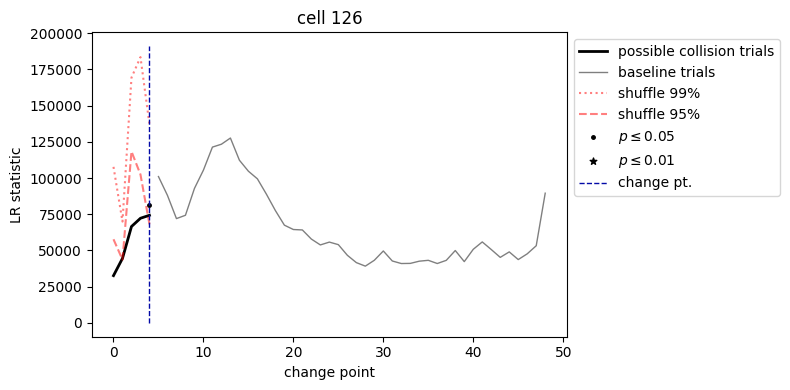

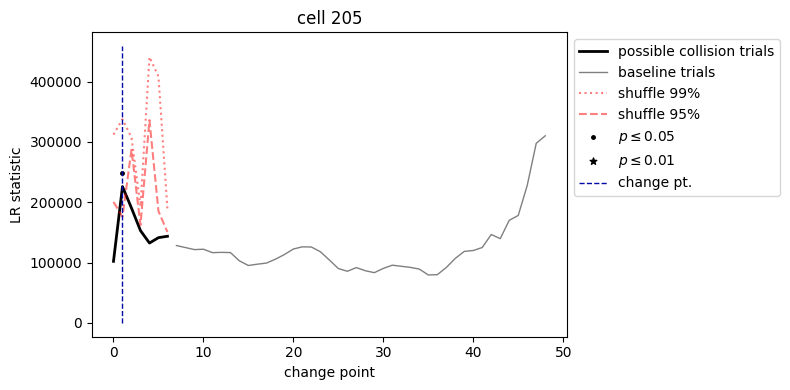

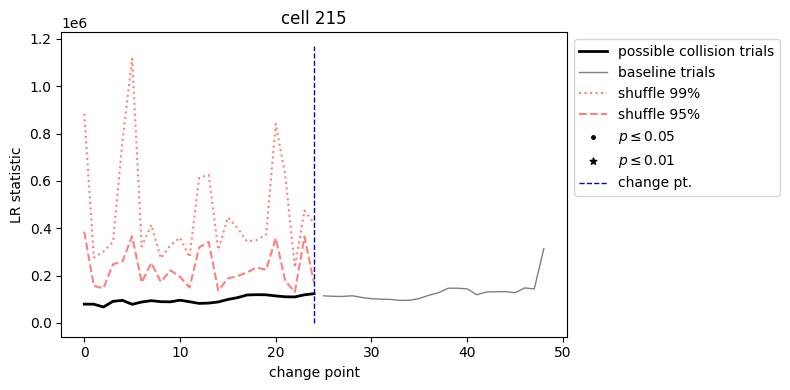

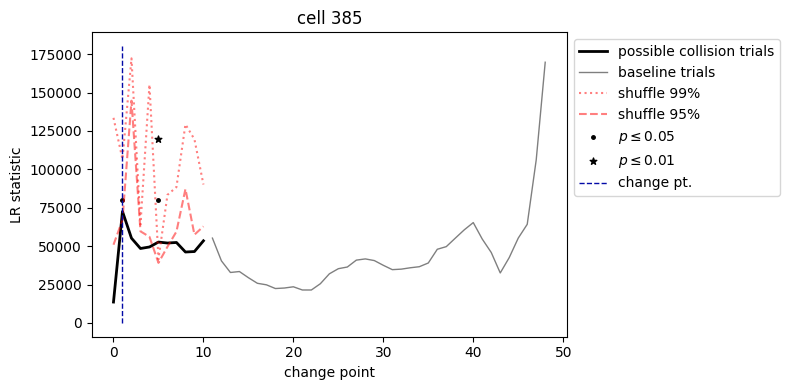

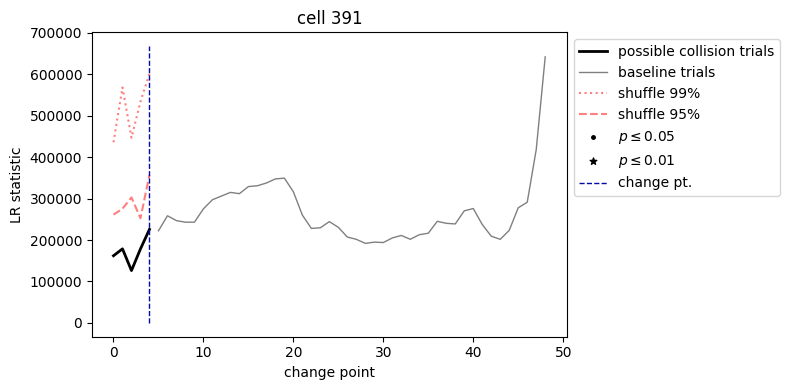

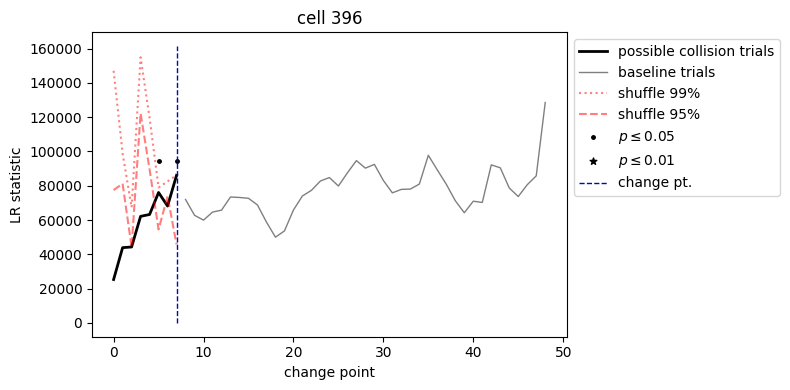

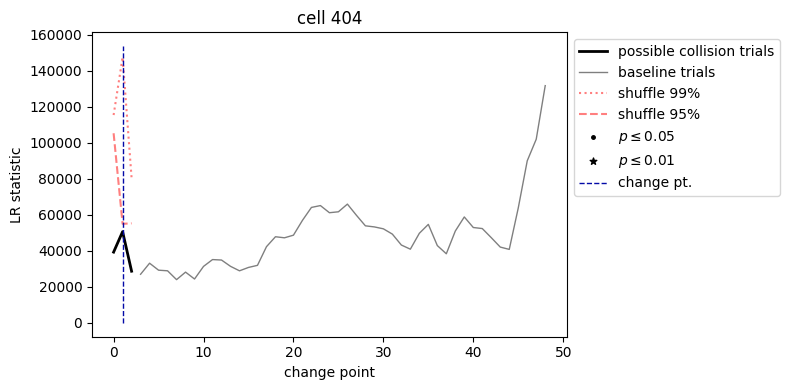

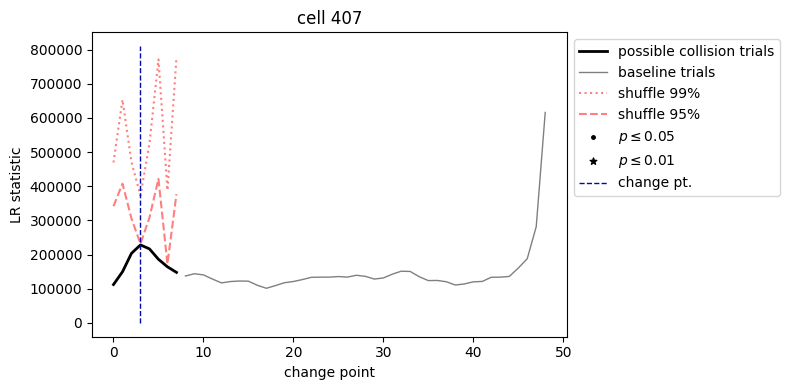

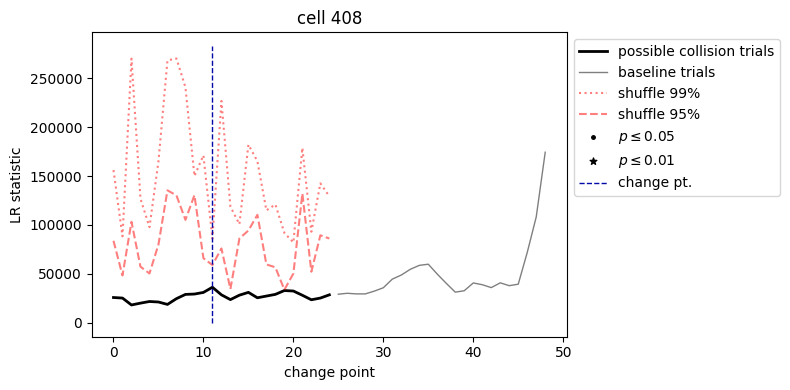

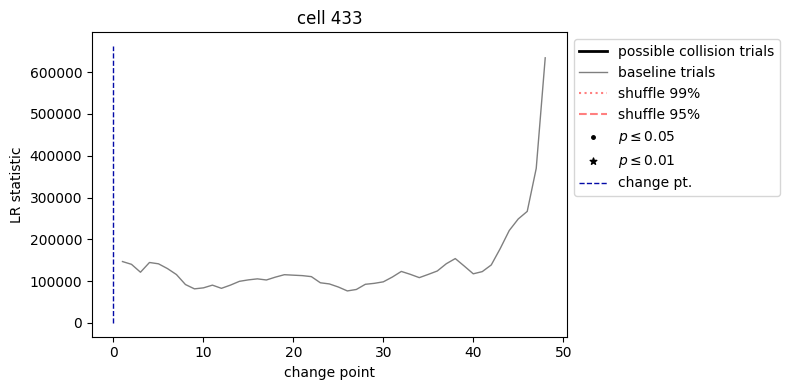

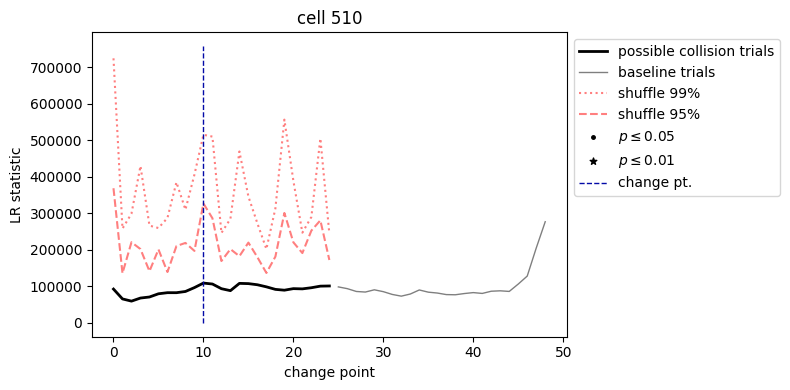

In [15]:
''' plot the shuffle LR vs. the cell LR and get significant change points (candidate collisions) '''
from scipy.signal import find_peaks

sig_LR = np.zeros((n_cells, n_samp, 2)).astype(bool)
for cell in range(n_cells):
    cell_LR = all_change_LR[cell]
    if np.isfinite(cell_LR):
        # data params
        change_pt = all_change_idx[cell]
        n_short = all_n_short[cell].astype(int)
        LR_cell = all_LR_all_cells[cell]
        n_dist = LR_cell.shape[0]
        LR_peaks_idx, _ = find_peaks(LR_cell[:n_short])
        LR_peaks_idx = np.append(np.insert(LR_peaks_idx, 0, 0), n_short-1)
        n_peaks = LR_peaks_idx.shape[0]

        # shuffle params
        this_shuff = shuffled_distances[cell, :n_dist]
        mean_shuff = np.mean(this_shuff, axis=0)
        shuff_99 = np.nanpercentile(this_shuff, 99, axis=0)
        shuff_95 = np.nanpercentile(this_shuff, 95, axis=0)
        
        # significant?
        if np.sum(LR_cell[LR_peaks_idx] >= shuff_95[LR_peaks_idx]):
            sig_LR[cell, LR_peaks_idx, 0] = LR_cell[LR_peaks_idx] >= shuff_95[LR_peaks_idx]
            if np.sum(LR_cell[LR_peaks_idx] >= shuff_99[LR_peaks_idx]):
                sig_LR[cell, LR_peaks_idx, 1] = LR_cell[LR_peaks_idx] >= shuff_99[LR_peaks_idx]
            
        # plotting params
        f, ax = plt.subplots(1, 1, figsize=(8, 4))
        trials = np.arange(n_dist)
        sig_yvals = np.full(n_peaks, np.max(LR_cell[:n_short])*1.1)

        # plot the data
        ax.plot(trials[:n_short], LR_cell[:n_short],
                'k', lw=2,
                label='possible collision trials')
        ax.plot(trials[n_short:], LR_cell[n_short:],
                'k', lw=1, alpha=0.5,
                label='baseline trials')

        # plot the shuffle
        ax.plot(shuff_99[:n_short],
                ':r', alpha=0.5,
                label='shuffle 99%')
        ax.plot(shuff_95[:n_short],
                '--r', alpha=0.5,
                label='shuffle 95%')

        # significant?
        sig_idx = LR_cell[LR_peaks_idx] >= shuff_95[LR_peaks_idx]
        ax.scatter(LR_peaks_idx[sig_idx], sig_yvals[sig_idx],
                   c='k', s=25, marker='.', label=r'$p \leq 0.05$')
        sig_idx = LR_cell[LR_peaks_idx] >= shuff_99[LR_peaks_idx]
        ax.scatter(LR_peaks_idx[sig_idx], sig_yvals[sig_idx]*1.5,
                   c='k', s=25, marker='*', label=r'$p \leq 0.01$')

        # plot the change point
        ylim = ax.get_ylim()
        ax.vlines(change_pt, 0, ylim[1],
                  colors='xkcd:cobalt blue',
                  linestyles='dashed', lw=1,
                  label=f'change pt.')

        # ticks, labels, lims
        ax.set_ylabel('LR statistic')
        ax.set_xlabel('change point')
        ax.legend(loc='upper left',
                  bbox_to_anchor=(1, 1))
        ax.set_title(f'cell {good_clusters[cell]}')

        plt.tight_layout()
        plt.show()

In [16]:
# any significant likelihood ratios?
idx_95 = np.sum(sig_LR, axis=1)[:, 0].astype(bool)
idx_99 = np.sum(sig_LR, axis=1)[:, 1].astype(bool)
print(f'{np.sum(idx_95)} cells have significant LR peaks (p <= .05)')
print(f'{np.sum(idx_99)} cells have significant LR peaks (p <= .01)')

# change point significant?
sig_change_pt = np.zeros((n_cells, 2)).astype(bool)
for cell in range(n_cells):
    change_idx = all_change_idx[cell]
    if np.isfinite(change_idx):
        cell_sig_LR = sig_LR[cell]
        sig_change_pt[cell] = cell_sig_LR[change_idx.astype(int)]
print(f'\n{np.sum(sig_change_pt, axis=0)[0]} cells have significant change points (p <= .05)')
print(f'{np.sum(sig_change_pt, axis=0)[1]} cells have significant change points (p <= .01)')

print(f'\nthese cells have significant LR peaks (p <= .01): {good_clusters[idx_99]}')

4 cells have significant LR peaks (p <= .05)
1 cells have significant LR peaks (p <= .01)

4 cells have significant change points (p <= .05)
0 cells have significant change points (p <= .01)

these cells have significant LR peaks (p <= .01): [385]


In [17]:
''' save properties for the significant cells '''
# cell IDs / indices
sig_cells = good_clusters[idx_99]
sig_cell_idx = np.arange(n_cells)[idx_99]

# collect the estimated collision latency, masked hash, LR
sig_lat = np.zeros(sig_cells.shape[0])
sig_masked_hash = []
sig_LR = []
for i, cell in enumerate(sig_cell_idx):
    lat_ms = pre_stim_spikes[cell][all_trial_idx[cell]]
    change_idx = all_change_idx[cell].astype(int)
    sig_lat[i] = lat_ms[change_idx]

    sig_masked_hash.append(all_hash_all_cells[cell])
    
    sig_LR.append(all_LR_all_cells[cell])

In [18]:
''' save the collision properties '''
collision_dir = session_dir

collision_prop_dict = {
    "sig_cell_IDs": sig_cells,
    "sig_cell_idx": sig_cell_idx,
    "n_short": all_n_short[sig_cell_idx],
    "masked_hash": sig_masked_hash,
    "LR_stat": sig_LR,
    "change_idx": all_change_idx[sig_cell_idx],
    "est_lat_ms": sig_lat,
    "trial_latencies": all_LR_latencies[sig_cell_idx]
}  
dict_file = f'{collision_dir}collision_props_{stim_pol}.npy'
np.save(dict_file, collision_prop_dict)

### Toggle the hash to check potential collisions

In [21]:
from ipywidgets import interact, widgets
%matplotlib widget

In [23]:
''' choose a cell to look at the toggled hash and get the data '''
sig_idx = 0
cell = sig_cell_idx[sig_idx]
n_wf_ch = 9

# data params
hash_masked = all_hash_all_cells[cell]
lat_cell = pre_stim_spikes[cell][all_trial_idx[cell]]
change_idx = all_change_idx[cell].astype(int)
best_ch = wf_ch_idx[cell]
n_short = all_n_short[cell]

lat_ms = np.round(lat_cell/sampling_rate*1000, 2)
trial_nums = np.arange(hash_masked.shape[0]-1) + 1

# get the absolute value of the hash
hash_abs = np.abs(hash_masked)

# mean hash for short latency trials
M1 = np.cumsum(hash_abs, axis=0)[:-1] / trial_nums[:, None, None]

# mean hash for long latency trials
M2 = np.cumsum(hash_abs[::-1], axis=0)[1:] / trial_nums[:, None, None]
M2 = M2[::-1]

print(f'cell {good_clusters[cell]} (idx {cell}): max collision latency = {lat_ms[change_idx]}')

# fig params
start_t = 5e-3
end_t = 15e-3
v_min = 10
v_max = 50
n_samp = M1.shape[-1]
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

# plot the baseline average hash
non_col = ax[1].imshow(M2[0], clim=[v_min, v_max],
                       aspect='auto', cmap='viridis')
ax[1].set_title(f'average remaining hash')

# plot the average hash for different latency cut-offs
put_col_im = ax[0].imshow(M1[0], clim=[v_min, v_max],
                           aspect='auto', cmap='viridis')
ax[0].set_title(f'average hash < {lat_ms[0]}ms')

# ticks and labels
n_bins = avg_hash.shape[1]
ax[0].set_yticks(np.arange(0, n_wf_ch, 2))
ax[0].set_yticklabels(np.arange(best_ch-n_wf_ch//2, best_ch+n_wf_ch//2+1, 2))
ax[0].set_ylabel('good channels')
ax[1].tick_params(labelleft=False)
for i in range(2):
    ax[i].set_ylim(ax[i].get_ylim()[::-1])
    ax[i].set_xticks(np.arange(0, n_samp+1, 0.002*sampling_rate))
    ax[i].set_xticklabels(np.arange(start_t*1000, end_t*1000 + 1, 2))
    ax[i].set_xlabel('time (ms)')

def update(idx):
    put_col_im.set_data(M1[idx])
    non_col.set_data(M2[idx])
    ax[0].set_title(f'average hash < {lat_ms[idx]}ms')
    fig.canvas.flush_events()
    fig.canvas.draw_idle()

interact(update, idx=widgets.IntSlider(min=0, max=n_short*2, step=1))

interactive(children=(IntSlider(value=0, description='idx', max=28), Output()), _dom_classes=('widget-interact…

<function __main__.update(idx)>

In [47]:
'''
SLV132 notes

session 250326
--------------
at 250uA:
    cells 49, 71 don't seem real (something funny going on for 71)
    cells 88, 255 looks legit and est latency seems about right
    cell 353 possibly something at ~7ms but est latency is off and collision timing doesn't seem quite right
    
at 350uA:
    cell 71 looks more legit, est latency roughly right, lots of overlapping spikes (should look at traces)
    cell 88 again looks good, est latency is off (more like ~7ms)
    cell 255 also looks good, est latency likely slightly high (seems more like 8-9ms)
    
session 250328
--------------
some high firing cells did not have enough long latency trials...
adjusted the minimum long latency from 20 to 16ms which might have been overkill and could maybe be impacting the results
at 350uA:
    things are generally confusing...4 "significant" units but nothing super convincing when toggling hash
at 250uA:
    9 significant units
    cell 295 definitely legit, response latency more like 8.5ms
    cell 328 yes definitely but lots of short latency trials shifted estimate a lot, real lat is ~7ms
    
    cell 134 possibly collision at ~8ms that is getting shifted bc lots of short latency trials
    cell 270 overlapping hash/a bit confusing but seems legit
    cells 256, 344, 376, 382 overlapping hash hard to say (try latencies ~8-9ms)
    
    cell 500 likely false positive
'''

-2147483648